# Euclidean GP Interpolation Failure on 1D Densities



In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel

try:
    import scienceplots  # noqa: F401
except Exception:
    scienceplots = None

plt.rcParams['figure.dpi'] = 180
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['axes.grid'] = False
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('retina')
except Exception:
    pass
try:
    import seaborn as sns
    sns.set_context('talk')
except Exception:
    sns = None

if scienceplots is not None:
    plt.style.use(['science'])


## Helper Functions

In [7]:
def gaussian_density(x, mean, sigma):
    """Evaluate the Gaussian PDF on a 1D grid."""
    z = (x - mean) / sigma
    return np.exp(-0.5 * z * z) / (np.sqrt(2.0 * np.pi) * sigma)


def normalize_density(x, p, eps=1e-14):
    """Project a nonnegative vector onto a normalized density on grid x."""
    p = np.clip(np.asarray(p, dtype=float), 0.0, None)
    area = np.trapezoid(p, x)
    if area <= eps:
        return np.ones_like(x) / (x[-1] - x[0])
    return p / area


def fit_density_gp(t_train, densities_train, length_scale=0.20, noise=1e-8):
    """Fit one scalar GP per spatial location x_j to p(x_j, t)."""
    t_train = np.asarray(t_train, dtype=float).reshape(-1, 1)
    densities_train = np.asarray(densities_train, dtype=float)

    kernel = (
        ConstantKernel(1.0, constant_value_bounds='fixed')
        * RBF(length_scale=length_scale, length_scale_bounds='fixed')
        + WhiteKernel(noise_level=noise, noise_level_bounds='fixed')
    )

    models = []
    for j in range(densities_train.shape[1]):
        gp = GaussianProcessRegressor(
            kernel=kernel,
            alpha=0.0,
            optimizer=None,
            normalize_y=False,
        )
        gp.fit(t_train, densities_train[:, j])
        models.append(gp)
    return models


def predict_density_gp(gp_models, t_query, x):
    """Predict densities at query times by independent-bin GP interpolation."""
    t_query = np.asarray(t_query, dtype=float).reshape(-1, 1)
    pred = np.column_stack([gp.predict(t_query) for gp in gp_models])

    pred = np.clip(pred, 0.0, None)
    pred = np.vstack([normalize_density(x, row) for row in pred])
    return pred


def wasserstein_interp_gaussian(x, t, m0, m1, sigma):
    """Closed-form 1D W2 geodesic between Gaussians with equal variance."""
    mean_t = (1.0 - t) * m0 + t * m1
    return normalize_density(x, gaussian_density(x, mean_t, sigma))


def density_mean_and_variance(x, p):
    """Compute mean and variance of a density on grid x."""
    p = normalize_density(x, p)
    mean = np.trapezoid(x * p, x)
    var = np.trapezoid((x - mean) ** 2 * p, x)
    return mean, var


def l2_density_error(x, p, q):
    """L2 error between two densities."""
    return np.sqrt(np.trapezoid((p - q) ** 2, x))


def w2_1d_from_densities(x, p, q, n_u=4096):
    """Compute W2 distance in 1D using inverse-CDF interpolation."""
    p = normalize_density(x, p)
    q = normalize_density(x, q)

    cdf_p = np.concatenate([[0.0], cumulative_trapezoid(p, x)])
    cdf_q = np.concatenate([[0.0], cumulative_trapezoid(q, x)])

    cdf_p = np.clip(np.maximum.accumulate(cdf_p), 0.0, 1.0)
    cdf_q = np.clip(np.maximum.accumulate(cdf_q), 0.0, 1.0)
    cdf_p[-1] = 1.0
    cdf_q[-1] = 1.0

    u = np.linspace(0.0, 1.0, n_u)
    q_p = np.interp(u, cdf_p, x)
    q_q = np.interp(u, cdf_q, x)

    return np.sqrt(np.trapezoid((q_p - q_q) ** 2, u))

## Experiment Setup and Data Generation

In [8]:
# Spatial domain
x_min, x_max = -5.0, 5.0
n_grid = 400
x = np.linspace(x_min, x_max, n_grid)

# True translating Gaussian path
m0, m1 = -2.0, 2.0
sigma = 0.25

def true_density(x, t, m0=m0, m1=m1, sigma=sigma):
    m_t = (1.0 - t) * m0 + t * m1
    return normalize_density(x, gaussian_density(x, m_t, sigma))

# Main demo: endpoint-only observations
t_train = np.array([0.0, 1.0])
t_test = np.linspace(0.0, 1.0, 101)

dens_train = np.vstack([true_density(x, t) for t in t_train])
dens_true = np.vstack([true_density(x, t) for t in t_test])
dens_wass = np.vstack([wasserstein_interp_gaussian(x, t, m0, m1, sigma) for t in t_test])

print(f'Grid points: {n_grid}')
print(f'Training times: {t_train.tolist()}')
print(f'Test times: {len(t_test)} points in [0, 1]')

Grid points: 400
Training times: [0.0, 1.0]
Test times: 101 points in [0, 1]


## Fit Euclidean GP Baseline and Predict Densities

In [9]:
gp_models = fit_density_gp(t_train, dens_train, length_scale=0.20, noise=1e-8)
dens_gp = predict_density_gp(gp_models, t_test, x)



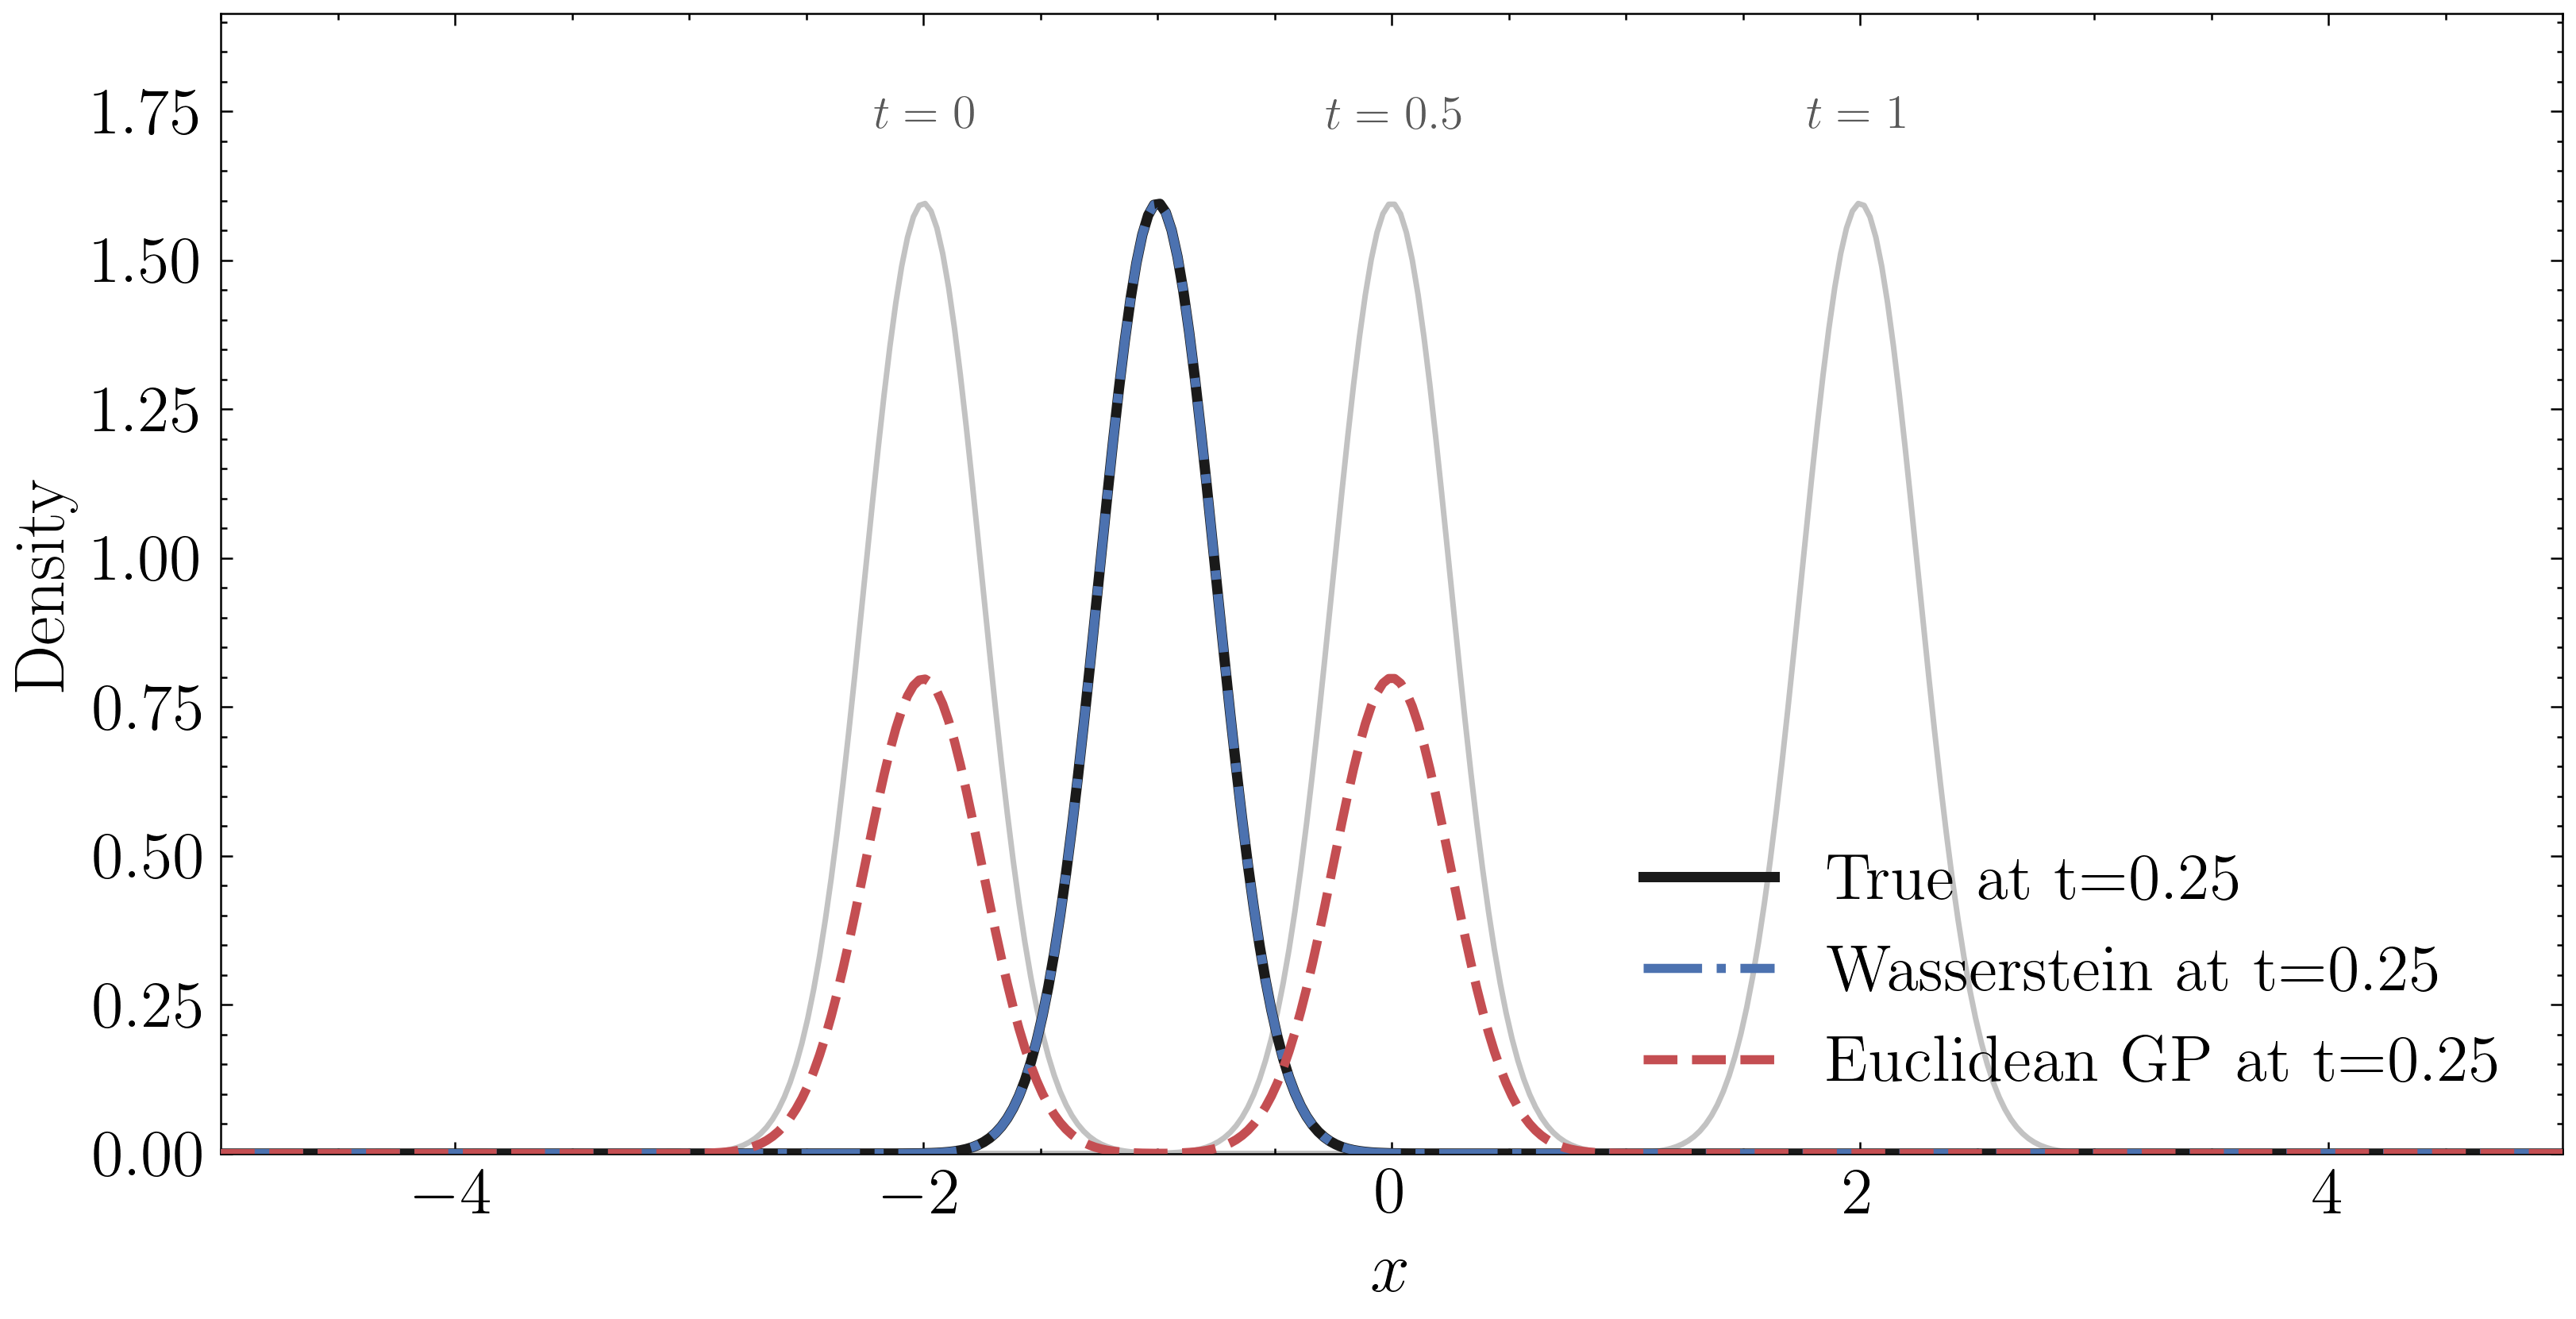

Saved: figures/euclidean_gp_density.pdf


In [11]:
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for p in (start, *start.parents):
        if (p / 'pyproject.toml').exists():
            return p
    return start


REPO_ROOT = _find_repo_root(Path.cwd())

# Assume observations at t = 0.0, 0.5, 1.0 and reconstruct at t = 0.25.
t_obs_key = np.array([0.0, 0.5, 1.0], dtype=float)
t_recon_key = 0.25

dens_obs_key = np.vstack([true_density(x, t) for t in t_obs_key])
dens_true_key = true_density(x, t_recon_key)

# Euclidean GP prediction at t=0.25 using the assumed observed set {0, 0.5, 1.0}.
gp_models_key = fit_density_gp(t_obs_key, dens_obs_key, length_scale=0.20, noise=1e-8)
dens_gp_key = predict_density_gp(gp_models_key, np.array([t_recon_key]), x)[0]

# Piecewise W2 interpolation between the neighboring observed times.
right_idx = int(np.searchsorted(t_obs_key, t_recon_key, side='right'))
left_idx = max(0, min(right_idx - 1, len(t_obs_key) - 2))
t_left, t_right = float(t_obs_key[left_idx]), float(t_obs_key[left_idx + 1])
tau_local = (t_recon_key - t_left) / (t_right - t_left)

m_left = (1.0 - t_left) * m0 + t_left * m1
m_right = (1.0 - t_right) * m0 + t_right * m1
dens_wass_key = wasserstein_interp_gaussian(x, tau_local, m_left, m_right, sigma)

fig, ax = plt.subplots(1, 1, figsize=(9.0, 4.6), constrained_layout=True)

# Plot observed densities and annotate each one directly.
for t_obs, p_obs in zip(t_obs_key, dens_obs_key):
    ax.plot(x, p_obs, color='0.75', linewidth=1.4, alpha=0.95, zorder=1)
    j = int(np.argmax(p_obs))
    ax.text(
        float(x[j]),
        float(p_obs[j]) * 1.07,
        f'$t={t_obs:g}$',
        ha='center',
        va='bottom',
        color='0.35',
        fontsize=12,
    )

ax.plot(x, dens_true_key, color='#1a1a1a', linewidth=2.6, label='True at t=0.25', zorder=3)
ax.plot(x, dens_wass_key, color='#4c72b0', linestyle='-.', linewidth=2.3, label='Wasserstein at t=0.25', zorder=3)
ax.plot(x, dens_gp_key, color='#c44e52', linestyle='--', linewidth=2.3, label='Euclidean GP at t=0.25', zorder=3)

ax.set_xlabel('$x$')
ax.set_ylabel('Density')
ax.set_xlim(x_min, x_max)
ax.grid(False)
ax.set_ylim(0.0, max(dens_true_key.max(), dens_wass_key.max(), dens_gp_key.max(), dens_obs_key.max()) * 1.2)
ax.legend(frameon=False, loc='lower right')

save_dir = REPO_ROOT / 'figures'
save_dir.mkdir(parents=True, exist_ok=True)
out_path = save_dir / 'euclidean_gp_density.pdf'
fig.savefig(out_path, format='pdf', bbox_inches='tight')

plt.show()

print(f'Saved: {out_path}')
